# Advanced Binary Classification: Gradient Boosting and XGBoost

In earlier notebooks, I built baseline and tuned binary classification models to predict whether a patient had at least one asthma exacerbation after treatment start.

The best model so far was tuned logistic regression, which improved recall but still had low precision and modest PR-AUC.

In this notebook, I will test more advanced tree-based boosting models to see whether they can improve binary exacerbation-risk prediction.

The binary target is:

- `0`: no post-index exacerbation
- `1`: at least one post-index exacerbation

## Modeling Plan

In this notebook, I will:

1. Load the processed train-test datasets.
2. Fit a scikit-learn gradient boosting model.
3. Fit a histogram gradient boosting model.
4. Fit an XGBoost classifier.
5. Tune selected model parameters using cross-validation.
6. Tune classification thresholds using training data only.
7. Evaluate final models on the held-out test set.
8. Compare advanced models with tuned logistic regression.

Because this is an imbalanced classification problem, I will focus on recall, precision, F1-score, ROC-AUC, and PR-AUC instead of accuracy alone.

In [1]:
# Importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")



In [3]:
try:
    from xgboost import XGBClassifier
    xgboost_available = True
    print("XGBoost is available.")
except ImportError:
    xgboost_available = False
    print("XGBoost is not installed in this environment.")

XGBoost is available.


## Load Processed Data

I will use the processed log-charge feature set created earlier.

The test set will be used only for final evaluation. Model tuning and threshold selection will be performed using the training data.

In [4]:
# Loading data

X_train = pd.read_csv("../data/processed/X_train_log.csv")
X_test = pd.read_csv("../data/processed/X_test_log.csv")

y_train = pd.read_csv("../data/processed/y_binary_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_binary_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (14572, 16)
X_test shape: (3643, 16)
y_train shape: (14572,)
y_test shape: (3643,)


In [5]:
# Checking class balance

class_balance = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "train_percent": y_train.value_counts(normalize=True).sort_index() * 100,
    "test_count": y_test.value_counts().sort_index(),
    "test_percent": y_test.value_counts(normalize=True).sort_index() * 100
})

class_balance


,train_count,train_percent,test_count,test_percent
had_exacerbation,,,,
0,12899,88.5191,3225,88.5259
1,1673,11.4809,418,11.4741


In [6]:
# Evaluation function

def evaluate_classifier(model_name, y_true, y_pred, y_proba=None):
    """
    Evaluate a binary classification model.
    Positive class = 1, meaning at least one post-index exacerbation.
    """
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_proba is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_proba)
        results["pr_auc"] = average_precision_score(y_true, y_proba)
    else:
        results["roc_auc"] = np.nan
        results["pr_auc"] = np.nan
    
    return pd.DataFrame([results])



In [7]:
# Cross validation set-up
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=22
)


## Baseline Reference from Previous Notebook

The best model from the previous tuning notebook was tuned logistic regression.

Its test-set performance was:

- Accuracy: 0.5059
- Precision: 0.1344
- Recall: 0.6077
- F1-score: 0.2201
- ROC-AUC: 0.5615
- PR-AUC: 0.1347

In this notebook, advanced models should be compared against this reference.

In [8]:
# Storing previous best model result

previous_best_results = pd.DataFrame({
    "model": ["Tuned Logistic Regression"],
    "accuracy": [0.5059],
    "precision": [0.1344],
    "recall": [0.6077],
    "f1": [0.2201],
    "roc_auc": [0.5615],
    "pr_auc": [0.1347]
})

previous_best_results


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned Logistic Regression,0.5059,0.1344,0.6077,0.2201,0.5615,0.1347


## Model 1: Gradient Boosting Classifier

Gradient Boosting is an ensemble method that builds decision trees sequentially. Each new tree tries to correct errors from the previous trees.

Unlike Random Forest, which builds many independent trees, Gradient Boosting builds trees in a staged way and can sometimes capture predictive patterns more effectively.

I will first tune a small set of parameters using cross-validation and PR-AUC as the scoring metric.

In [9]:
# Gradient Boosting Grid search

gb_model = GradientBoostingClassifier(
    random_state=22
)

gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_leaf": [5, 10, 20]
}

gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gb_grid.fit(X_train, y_train)

print("Best parameters:", gb_grid.best_params_)
print("Best cross-validated PR-AUC:", gb_grid.best_score_)


Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 200}
Best cross-validated PR-AUC: 0.14132116202226525


In [10]:
# Threshold Tuning for Gradient Boosting

best_gb = gb_grid.best_estimator_

gb_cv_proba = cross_val_predict(
    best_gb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

pd.Series(gb_cv_proba).describe()


count   14572.0000
mean        0.1146
std         0.0393
min         0.0113
25%         0.0868
50%         0.1100
75%         0.1349
max         0.5383
dtype: float64

In [11]:
thresholds = np.arange(0.05, 0.51, 0.01)

gb_threshold_results = []

for threshold in thresholds:
    y_train_pred_threshold = (gb_cv_proba >= threshold).astype(int)
    
    gb_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_train, y_train_pred_threshold),
        "precision": precision_score(y_train, y_train_pred_threshold, zero_division=0),
        "recall": recall_score(y_train, y_train_pred_threshold, zero_division=0),
        "f1": f1_score(y_train, y_train_pred_threshold, zero_division=0)
    })

gb_threshold_results = pd.DataFrame(gb_threshold_results)

gb_threshold_results.sort_values("f1", ascending=False).head(10)


,threshold,accuracy,precision,recall,f1
5,0.1000,0.4386,0.1323,0.6999,0.2226
7,0.1200,0.6042,0.1431,0.4907,0.2216
6,0.1100,0.5215,0.1362,0.5929,0.2215
4,0.0900,0.3529,0.1272,0.7914,0.2192
3,0.0800,0.2659,0.1237,0.8870,0.2172
2,0.0700,0.1892,0.1195,0.9516,0.2123
8,0.1300,0.6790,0.1464,0.3718,0.2101
1,0.0600,0.1428,0.1167,0.9839,0.2086
0,0.0500,0.1229,0.1153,0.9946,0.2066
9,0.1400,0.7381,0.1500,0.2744,0.1939


In [12]:
best_gb_threshold_row = gb_threshold_results.loc[
    gb_threshold_results["f1"].idxmax()
]

best_gb_threshold = best_gb_threshold_row["threshold"]

best_gb_threshold_row



threshold   0.1000
accuracy    0.4386
precision   0.1323
recall      0.6999
f1          0.2226
Name: 5, dtype: float64

In [13]:
# Final Gradient Boosting Test Evaluation

best_gb.fit(X_train, y_train)

gb_test_proba = best_gb.predict_proba(X_test)[:, 1]
gb_test_pred = (gb_test_proba >= best_gb_threshold).astype(int)

gb_test_results = evaluate_classifier(
    model_name="Tuned Gradient Boosting",
    y_true=y_test,
    y_pred=gb_test_pred,
    y_proba=gb_test_proba
)

gb_test_results



,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned Gradient Boosting,0.4225,0.1206,0.6411,0.2030,0.5328,0.1259


In [14]:
confusion_matrix(y_test, gb_test_pred)


array([[1271, 1954],
       [ 150,  268]])

In [15]:
print(classification_report(y_test, gb_test_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.89      0.39      0.55      3225
           1       0.12      0.64      0.20       418

    accuracy                           0.42      3643
   macro avg       0.51      0.52      0.38      3643
weighted avg       0.81      0.42      0.51      3643



## Observation: Tuned Gradient Boosting

The tuned Gradient Boosting model selected the following parameters:

- `learning_rate`: **0.1**
- `max_depth`: **2**
- `min_samples_leaf`: **5**
- `n_estimators`: **200**

The best cross-validated PR-AUC was **0.1413**, which was slightly lower than the tuned logistic regression model from the previous notebook.

Using cross-validated training predictions, the best F1-score was observed at a threshold of **0.10**. This threshold is reasonable because the predicted probabilities were centered around 0.11.

On the held-out test set, tuned Gradient Boosting achieved:

- Accuracy: **0.4225**
- Precision: **0.1206**
- Recall: **0.6411**
- F1-score: **0.2030**
- ROC-AUC: **0.5328**
- PR-AUC: **0.1259**

The model identified **268 out of 418** patients who actually had at least one exacerbation. This gave a higher recall than tuned logistic regression. However, it also produced **1,954 false positives**, leading to lower precision.

Compared with tuned logistic regression, Gradient Boosting improved recall but had lower precision, F1-score, ROC-AUC, and PR-AUC. Therefore, it does not clearly improve the overall model performance.


## Model 2: XGBoost Classifier

Since XGBoost is available in this environment, I will test an XGBoost classifier.

XGBoost is a gradient boosting algorithm that often performs well on tabular datasets. It can model non-linear relationships and interactions between predictors.

Because the dataset is imbalanced, I will use `scale_pos_weight`, which gives more weight to the positive class during training. This value is calculated as:

negative training cases / positive training cases

This helps the model pay more attention to patients who had at least one exacerbation.

In [16]:
# To Calculate scale_pos_weight

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative count:", negative_count)
print("Positive count:", positive_count)
print("scale_pos_weight:", scale_pos_weight)


Negative count: 12899
Positive count: 1673
scale_pos_weight: 7.710101613867304


In [17]:
# XGBoost Grid Search

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=22,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best cross-validated PR-AUC:", xgb_grid.best_score_)



Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validated PR-AUC: 0.14289225420409757


In [18]:
#Cross-Validated XGBoost Probabilities

best_xgb = xgb_grid.best_estimator_

xgb_cv_proba = cross_val_predict(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

pd.Series(xgb_cv_proba).describe()


count   14572.0000
mean        0.4903
std         0.0599
min         0.2879
25%         0.4424
50%         0.4978
75%         0.5351
max         0.6883
dtype: float64

In [19]:
# Threshold Tuning for XGBoost

thresholds = np.arange(0.05, 0.51, 0.01)

xgb_threshold_results = []

for threshold in thresholds:
    y_train_pred_threshold = (xgb_cv_proba >= threshold).astype(int)
    
    xgb_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_train, y_train_pred_threshold),
        "precision": precision_score(y_train, y_train_pred_threshold, zero_division=0),
        "recall": recall_score(y_train, y_train_pred_threshold, zero_division=0),
        "f1": f1_score(y_train, y_train_pred_threshold, zero_division=0)
    })

xgb_threshold_results = pd.DataFrame(xgb_threshold_results)

xgb_threshold_results.sort_values("f1", ascending=False).head(10)



,threshold,accuracy,precision,recall,f1
44,0.4900,0.4960,0.1373,0.6420,0.2263
43,0.4800,0.4629,0.1353,0.6820,0.2258
45,0.5000,0.5328,0.1389,0.5906,0.2250
41,0.4600,0.3920,0.1314,0.7657,0.2243
42,0.4700,0.4273,0.1321,0.7161,0.2231
40,0.4500,0.3544,0.1290,0.8039,0.2224
39,0.4400,0.3171,0.1270,0.8428,0.2208
38,0.4300,0.2779,0.1239,0.8715,0.2170
37,0.4200,0.2405,0.1212,0.8984,0.2136
36,0.4100,0.2090,0.1197,0.9271,0.2121


In [20]:
# To Select Best XGBoost Threshold

best_xgb_threshold_row = xgb_threshold_results.loc[
    xgb_threshold_results["f1"].idxmax()
]

best_xgb_threshold = best_xgb_threshold_row["threshold"]

best_xgb_threshold_row


threshold   0.4900
accuracy    0.4960
precision   0.1373
recall      0.6420
f1          0.2263
Name: 44, dtype: float64

In [21]:
# Final XGBoost Test Evaluation

best_xgb.fit(X_train, y_train)

xgb_test_proba = best_xgb.predict_proba(X_test)[:, 1]
xgb_test_pred = (xgb_test_proba >= best_xgb_threshold).astype(int)

xgb_test_results = evaluate_classifier(
    model_name="Tuned XGBoost",
    y_true=y_test,
    y_pred=xgb_test_pred,
    y_proba=xgb_test_proba
)

xgb_test_results


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned XGBoost,0.4776,0.1267,0.6029,0.2094,0.5469,0.1347


In [22]:
confusion_matrix(y_test, xgb_test_pred)

array([[1488, 1737],
       [ 166,  252]])

In [23]:
print(classification_report(y_test, xgb_test_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.90      0.46      0.61      3225
           1       0.13      0.60      0.21       418

    accuracy                           0.48      3643
   macro avg       0.51      0.53      0.41      3643
weighted avg       0.81      0.48      0.56      3643



## Observation: Tuned XGBoost

The XGBoost model used `scale_pos_weight` to address class imbalance. The calculated value was **7.71**, meaning the negative class was about 7.7 times larger than the positive class in the training data.

The best XGBoost parameters were:

- `colsample_bytree`: **0.8**
- `learning_rate`: **0.03**
- `max_depth`: **2**
- `n_estimators`: **100**
- `subsample`: **0.8**

The best cross-validated PR-AUC was **0.1429**, which was close to but slightly lower than the tuned logistic regression model from the previous notebook.

Using cross-validated training predictions, the best F1-score was observed at a threshold of **0.49**.

On the held-out test set, tuned XGBoost achieved:

- Accuracy: **0.4776**
- Precision: **0.1267**
- Recall: **0.6029**
- F1-score: **0.2094**
- ROC-AUC: **0.5469**
- PR-AUC: **0.1347**

The model identified **252 out of 418** patients who actually had at least one exacerbation. This recall was similar to tuned logistic regression, but XGBoost had lower precision and F1-score.

Overall, XGBoost did not clearly improve the binary classification task compared with tuned logistic regression. This suggests that the main limitation may be weak predictive signal in the available features rather than model complexity alone.




In [24]:
# model comparison with previous best

advanced_model_comparison = pd.concat(
    [
        previous_best_results,
        gb_test_results,
        xgb_test_results
    ],
    ignore_index=True
)

advanced_model_comparison


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned Logistic Regression,0.5059,0.1344,0.6077,0.2201,0.5615,0.1347
1,Tuned Gradient Boosting,0.4225,0.1206,0.6411,0.2030,0.5328,0.1259
2,Tuned XGBoost,0.4776,0.1267,0.6029,0.2094,0.5469,0.1347


In [25]:
# Sort by F1 and PR-AUC

advanced_model_comparison.sort_values(
    by=["f1", "pr_auc"],
    ascending=False
)



,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Tuned Logistic Regression,0.5059,0.1344,0.6077,0.2201,0.5615,0.1347
2,Tuned XGBoost,0.4776,0.1267,0.6029,0.2094,0.5469,0.1347
1,Tuned Gradient Boosting,0.4225,0.1206,0.6411,0.2030,0.5328,0.1259


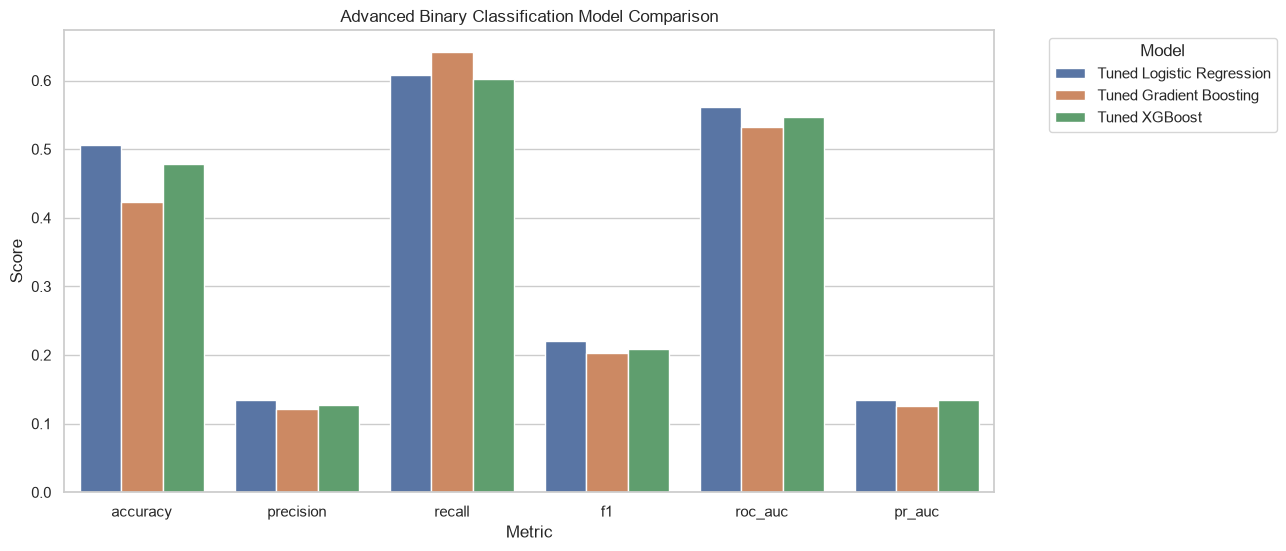

In [26]:
# Plotting Advanced Model for Comparison

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

advanced_results_long = advanced_model_comparison.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=advanced_results_long,
    x="metric",
    y="score",
    hue="model"
)

plt.title("Advanced Binary Classification Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


## Observation: Advanced Model Comparison

The advanced models were compared with the previous best model, tuned logistic regression.

The results show that advanced boosting models did not clearly outperform tuned logistic regression.

Tuned logistic regression achieved:

- Precision: **0.1344**
- Recall: **0.6077**
- F1-score: **0.2201**
- ROC-AUC: **0.5615**
- PR-AUC: **0.1347**

Tuned XGBoost achieved:

- Precision: **0.1267**
- Recall: **0.6029**
- F1-score: **0.2094**
- ROC-AUC: **0.5469**
- PR-AUC: **0.1347**

Tuned Gradient Boosting achieved:

- Precision: **0.1206**
- Recall: **0.6411**
- F1-score: **0.2030**
- ROC-AUC: **0.5328**
- PR-AUC: **0.1259**

Gradient Boosting had the highest recall, but it also had the lowest precision, lowest F1-score, and lowest PR-AUC among the three compared models. This means it identified more positive cases but produced many false positives.

XGBoost performed similarly to tuned logistic regression in recall and PR-AUC, but it did not improve F1-score or ROC-AUC.

Overall, tuned logistic regression remains the preferred model because it provides the best overall balance among the tested models and is easier to interpret.

## XGBoost Feature Importance

Although XGBoost did not outperform tuned logistic regression, I will inspect its feature importance values to understand which predictors were most useful to the model.

These importance values are not causal effects. They only indicate which features the model used most often or found useful for splitting.

In [27]:
xgb_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

xgb_feature_importance


,feature,importance
10,pre_asthma_days,0.1373
14,log_charges,0.1238
13,female,0.0866
11,pre_asthma_pharma_charge,0.0728
4,acute_bronchitis,0.0725
5,acute_laryngitis,0.0668
3,sinusitis,0.0643
15,log_asthma_charge,0.0638
8,rhinitis,0.0581
7,gerd,0.0573


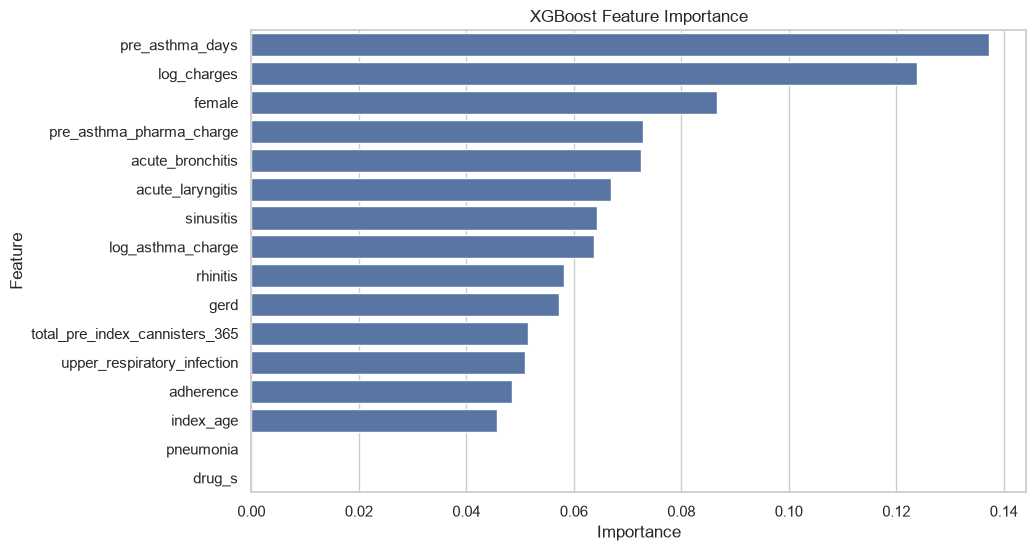

In [28]:
# plotting them

plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_feature_importance,
    x="importance",
    y="feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Observation: XGBoost Feature Importance

The top XGBoost feature importance values were observed for:

1. **pre_asthma_days**
2. **log_charges**
3. **female**
4. **pre_asthma_pharma_charge**
5. **acute_bronchitis**

Other important features included **acute_laryngitis**, **sinusitis**, **log_asthma_charge**, **rhinitis**, and **GERD**.

These results show that XGBoost used a mixture of healthcare utilization variables, demographic information, charge-related variables, and respiratory diagnosis indicators.

Interestingly, `pneumonia` and `drug_s` had feature importance values of **0.0000** in this tuned XGBoost model. This suggests that the model did not find these variables useful for splitting under the selected hyperparameter settings.

The importance of `pre_asthma_days`, `log_charges`, and `pre_asthma_pharma_charge` suggests that baseline healthcare utilization and cost-related variables may contain useful information about future exacerbation risk. The importance of diagnosis variables such as `acute_bronchitis`, `acute_laryngitis`, `sinusitis`, `rhinitis`, and `GERD` is also consistent with earlier exploratory findings.

However, these feature importance values should not be interpreted as causal effects. They only show which features were useful for prediction in this specific XGBoost model.


# Summary of Advanced Binary Classification Modeling

In this notebook, I tested advanced tree-based boosting models for the binary asthma exacerbation prediction task.

The models evaluated were:

1. Tuned Gradient Boosting
2. Tuned XGBoost
3. Tuned Logistic Regression from the previous notebook as the reference model

The goal was to determine whether advanced boosting models could improve prediction of patients who had at least one post-index asthma exacerbation.

The final comparison showed that tuned logistic regression remained the strongest overall model among the tested approaches.

The final model comparison was:

| Model | Precision | Recall | F1-score | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|
| Tuned Logistic Regression | 0.1344 | 0.6077 | 0.2201 | 0.5615 | 0.1347 |
| Tuned XGBoost | 0.1267 | 0.6029 | 0.2094 | 0.5469 | 0.1347 |
| Tuned Gradient Boosting | 0.1206 | 0.6411 | 0.2030 | 0.5328 | 0.1259 |

Gradient Boosting achieved the highest recall, identifying more positive cases, but it produced many false positives and had lower precision and F1-score.

XGBoost performed similarly to tuned logistic regression in recall and PR-AUC, but it did not improve the overall performance.

Overall, the advanced models did not clearly improve the prediction task. This suggests that the main limitation may be the available feature signal rather than model complexity alone.

For this project, the preferred binary classification model remains **tuned logistic regression**, because it provides the best balance of recall, F1-score, ROC-AUC, PR-AUC, and interpretability.



# Project-Level Interpretation

Across the binary classification, count prediction, and advanced modeling notebooks, one consistent pattern emerged: predicting future asthma exacerbations from the available pre-index variables is difficult.

The dataset is highly imbalanced and zero-heavy. Most patients had no post-index exacerbation, and only a small percentage had one or more events. This made both binary classification and exact count prediction challenging.

The models were able to detect some signal, especially from variables related to baseline healthcare charges, respiratory diagnoses, sex, and healthcare utilization. However, overall model performance remained modest.

This is an important real-world machine learning lesson. More complex models do not always produce better results. In this project, careful preprocessing, threshold tuning, and model evaluation were more informative than simply applying advanced algorithms.

The final modeling results suggest that the dataset may be more useful for exploratory risk stratification than for high-confidence individual-level prediction.
